In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
df = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv')

In [17]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [18]:
df.shape

(301, 9)

In [19]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [20]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [22]:
from os import dup
duplicate_count = df.duplicated().sum()
print('Duplcate Rows', duplicate_count)

Duplcate Rows 2


In [24]:
df = df.drop_duplicates().copy()
print('Duplicate remaining',df.duplicated().sum)

Duplicate remaining <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 299, dtype: bool>


In [25]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [26]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [27]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [29]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

df[["Car_Name", "Year", "Car_Age"]].head()

,Car_Name,Year,Car_Age
0,ritz,2014,12
1,sx4,2013,13
2,ciaz,2017,9
3,wagon r,2011,15
4,swift,2014,12


In [30]:
expensive_cars = df.sort_values(
    by="Selling_Price",
    ascending=False
)

expensive_cars[["Car_Name", "Selling_Price", "Present_Price"]].head(10)

,Car_Name,Selling_Price,Present_Price
86,land cruiser,35.00,92.60
64,fortuner,33.00,36.23
63,fortuner,23.50,35.96
82,innova,23.00,25.39
51,fortuner,23.00,30.61
96,innova,20.75,25.39
59,fortuner,19.99,35.96
66,innova,19.75,23.15
62,fortuner,18.75,35.96
52,innova,18.00,19.77


In [31]:
fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean()

print(fuel_price)

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


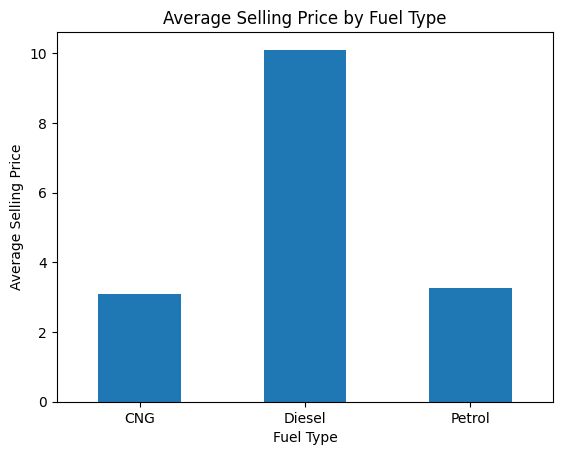

In [32]:
fuel_price.plot(kind="bar")

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()

In [33]:
transmission_price = df.groupby("Transmission")["Selling_Price"].mean()

print(transmission_price)

Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


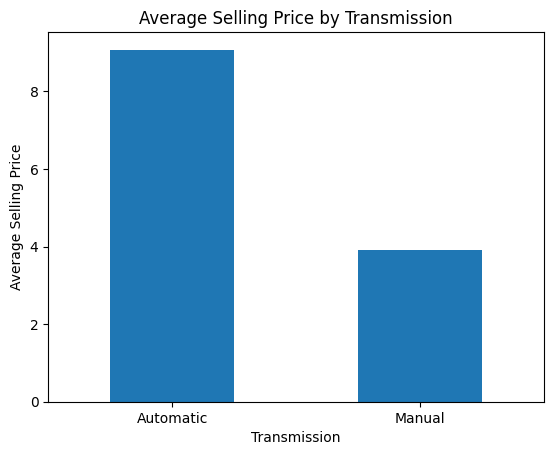

In [34]:
transmission_price.plot(kind="bar")

plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()

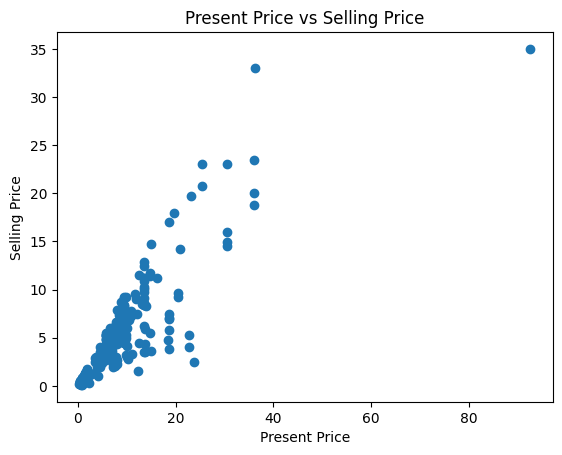

In [35]:
plt.scatter(df["Present_Price"], df["Selling_Price"])

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

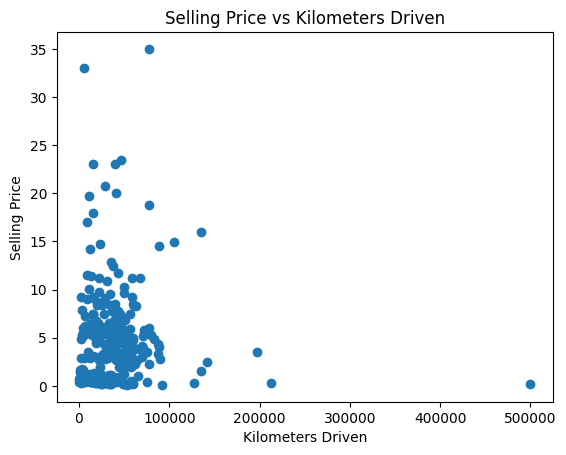

In [36]:
plt.scatter(df["Kms_Driven"], df["Selling_Price"])

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

In [37]:
fuel_count = df["Fuel_Type"].value_counts()

print(fuel_count)

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


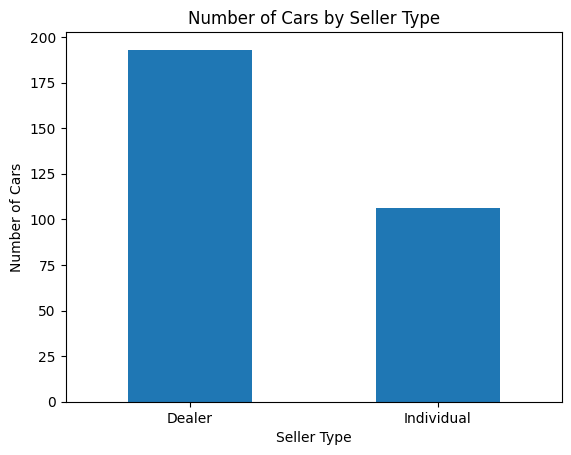

In [43]:
seller_count= df['Seller_Type'].value_counts()
seller_count.plot(kind="bar")

plt.title("Number of Cars by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.show()

In [40]:
transmission_count = df["Transmission"].value_counts()

print(transmission_count)

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


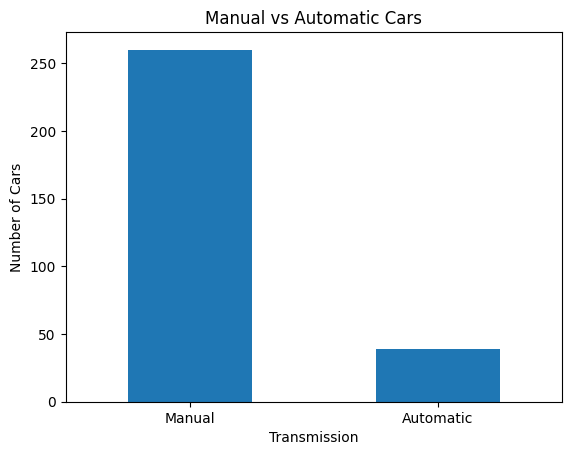

In [41]:
transmission_count.plot(kind="bar")

plt.title("Manual vs Automatic Cars")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.show()

In [44]:
numeric_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

correlation = df[numeric_columns].corr()

print(correlation)

                   Year  Selling_Price  Present_Price  Kms_Driven     Owner  \
Year           1.000000       0.234369      -0.053563   -0.525714 -0.181639   
Selling_Price  0.234369       1.000000       0.876378    0.028566 -0.087880   
Present_Price -0.053563       0.876378       1.000000    0.205253  0.009947   
Kms_Driven    -0.525714       0.028566       0.205253    1.000000  0.089367   
Owner         -0.181639      -0.087880       0.009947    0.089367  1.000000   
Car_Age       -1.000000      -0.234369       0.053563    0.525714  0.181639   

                Car_Age  
Year          -1.000000  
Selling_Price -0.234369  
Present_Price  0.053563  
Kms_Driven     0.525714  
Owner          0.181639  
Car_Age        1.000000  


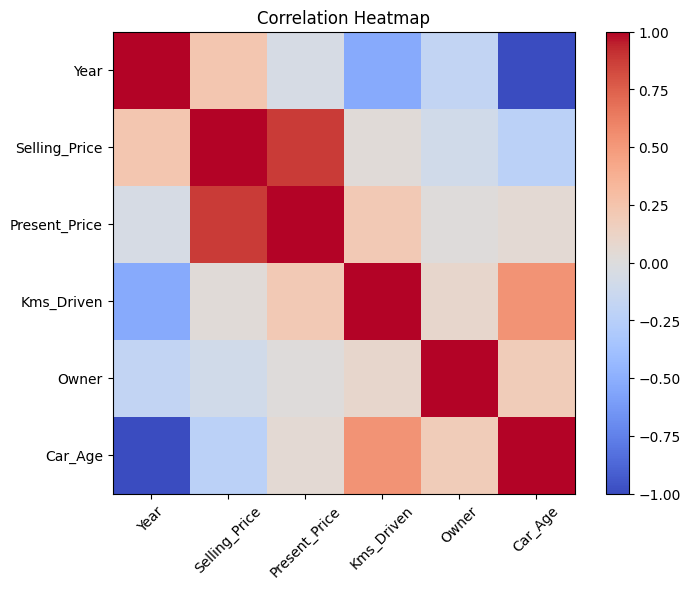

In [45]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [46]:
top_cars = df["Car_Name"].value_counts().head(10)

print(top_cars)

Car_Name
city                         26
corolla altis                16
verna                        14
brio                         10
fortuner                     10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64


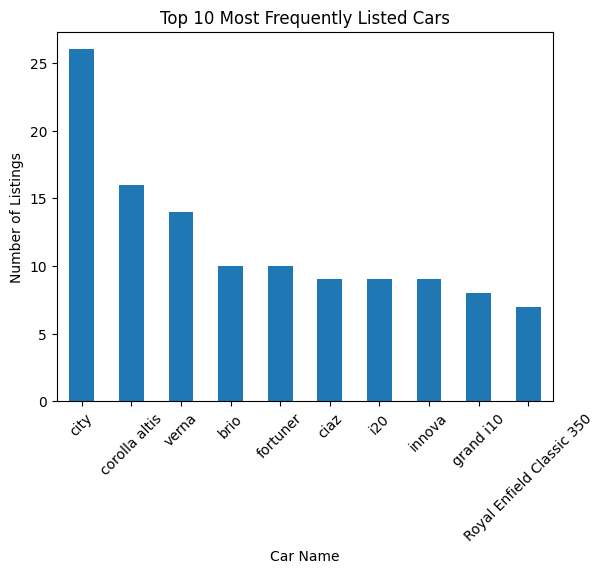

In [47]:
top_cars.plot(kind="bar")

plt.title("Top 10 Most Frequently Listed Cars")
plt.xlabel("Car Name")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

In [48]:
age_price = df.groupby("Car_Age")["Selling_Price"].mean()

print(age_price)

Car_Age
8     9.250000
9     6.209143
10    5.161429
11    5.642500
12    4.762105
13    3.540909
14    3.841304
15    2.375263
16    5.262667
17    2.816667
18    1.002857
19    0.160000
20    1.437500
21    2.487500
22    1.500000
23    1.300000
Name: Selling_Price, dtype: float64


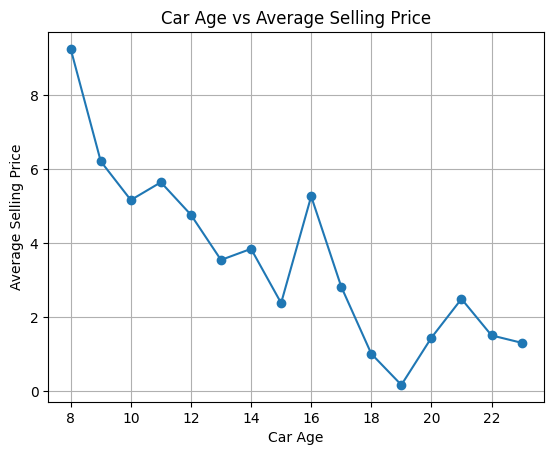

In [49]:
plt.plot(age_price.index, age_price.values, marker="o")

plt.title("Car Age vs Average Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Average Selling Price")
plt.grid(True)

plt.show()

In [50]:
print("Total number of cars:", len(df))

print("Average selling price:",
      round(df["Selling_Price"].mean(), 2))

print("Average present price:",
      round(df["Present_Price"].mean(), 2))

print("Most common fuel type:",
      df["Fuel_Type"].mode()[0])

print("Most common transmission:",
      df["Transmission"].mode()[0])

print("Most common seller type:",
      df["Seller_Type"].mode()[0])

print("Most listed car:",
      df["Car_Name"].mode()[0])

Total number of cars: 299
Average selling price: 4.59
Average present price: 7.54
Most common fuel type: Petrol
Most common transmission: Manual
Most common seller type: Dealer
Most listed car: city
